In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42


In [2]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_val   = pd.read_csv("y_val.csv")

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

#making the databases python readable

(73271, 44) (18318, 44)
(73271, 1) (18318, 1)


In [3]:
y_train = y_train.squeeze()
y_val = y_val.squeeze()

type(y_train), y_train.shape


(pandas.core.series.Series, (73271,))

In [4]:
X_train.dtypes.value_counts()


object    33
int64     11
Name: count, dtype: int64

In [5]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))


Categorical columns: 33
Numerical columns: 11


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_train_processed.shape


(73271, 2256)

In [10]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Import Pipeline to chain preprocessing + model together
from sklearn.pipeline import Pipeline

# Create the Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,          # Number of trees in the forest (more = more stable, slower)
    random_state=42,           # Fixes randomness so results are reproducible
    n_jobs=-1,                 # Use all available CPU cores
    class_weight="balanced"    # Adjusts for class imbalance (important for readmission)
)

# Build a single pipeline that:
# 1) preprocesses the data
# 2) trains the Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),  # Cleans + encodes the raw input features
    ("model", rf)                    # Trains the Random Forest on processed data
])

# Fit the entire pipeline:
# - preprocessor.fit_transform(X_train)
# - model.fit(X_train_processed, y_train)
rf_pipeline.fit(X_train, y_train)

print("Trained ✅")


Trained ✅


In [11]:
# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions on validation data
# NOTE: preprocessing is applied automatically using the fitted preprocessor
y_pred = rf_pipeline.predict(X_val)

# Display confusion matrix:
# Rows = true labels
# Columns = predicted labels
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))

# Display precision, recall, and F1-score for each class
# digits=3 just formats the output nicely
print("\nReport:\n", classification_report(y_val, y_pred, digits=3))


Confusion matrix:
 [[8716 1150    5]
 [4526 1858   14]
 [1344  685   20]]

Report:
               precision    recall  f1-score   support

           0      0.598     0.883     0.713      9871
           1      0.503     0.290     0.368      6398
           2      0.513     0.010     0.019      2049

    accuracy                          0.578     18318
   macro avg      0.538     0.394     0.367     18318
weighted avg      0.555     0.578     0.515     18318



In [12]:
 # Show proportion of each class in the training set
# normalize=True converts counts into percentages
print("y_train distribution:\n", y_train.value_counts(normalize=True))

# Same check for validation set
print("\ny_val distribution:\n", y_val.value_counts(normalize=True))


y_train distribution:
 readmitted
0    0.538876
1    0.349265
2    0.111859
Name: proportion, dtype: float64

y_val distribution:
 readmitted
0    0.538869
1    0.349274
2    0.111857
Name: proportion, dtype: float64


In [13]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,              # LIMIT depth
    min_samples_leaf=50,       # FORCE leaves to represent more patients
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),  # same preprocessor as before
    ("model", rf)                    # your new tuned RandomForestClassifier
])

rf_pipeline.fit(X_train, y_train)
print("Trained tuned RF ✅")



y_pred = rf_pipeline.predict(X_val)

print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))
print("\nReport:\n", classification_report(y_val, y_pred, digits=3))


Trained tuned RF ✅
Confusion matrix:
 [[5950 1478 2443]
 [2391 1592 2415]
 [ 656  386 1007]]

Report:
               precision    recall  f1-score   support

           0      0.661     0.603     0.631      9871
           1      0.461     0.249     0.323      6398
           2      0.172     0.491     0.254      2049

    accuracy                          0.467     18318
   macro avg      0.431     0.448     0.403     18318
weighted avg      0.536     0.467     0.481     18318



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

def fit_eval_rf(params, name="RF"):
    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        **params
    )
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    print(f"\n===== {name} =====")
    print("Params:", params)
    print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))
    print("\nReport:\n", classification_report(y_val, y_pred, digits=3))
    return pipe


In [16]:
pipe_1 = fit_eval_rf(
    {"n_estimators": 500, "max_depth": 20, "min_samples_leaf": 20},
    name="Try 1: less strict"
)



===== Try 1: less strict =====
Params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 20}
Confusion matrix:
 [[6009 1625 2237]
 [2368 1800 2230]
 [ 632  455  962]]

Report:
               precision    recall  f1-score   support

           0      0.667     0.609     0.637      9871
           1      0.464     0.281     0.350      6398
           2      0.177     0.469     0.257      2049

    accuracy                          0.479     18318
   macro avg      0.436     0.453     0.415     18318
weighted avg      0.541     0.479     0.494     18318



In [17]:
pipe_3 = fit_eval_rf(
    {"n_estimators": 600, "max_depth": 15, "min_samples_leaf": 50, "max_features": "sqrt"},
    name="Try 3: +max_features=sqrt"
)



===== Try 3: +max_features=sqrt =====
Params: {'n_estimators': 600, 'max_depth': 15, 'min_samples_leaf': 50, 'max_features': 'sqrt'}
Confusion matrix:
 [[5958 1508 2405]
 [2413 1620 2365]
 [ 658  394  997]]

Report:
               precision    recall  f1-score   support

           0      0.660     0.604     0.630      9871
           1      0.460     0.253     0.327      6398
           2      0.173     0.487     0.255      2049

    accuracy                          0.468     18318
   macro avg      0.431     0.448     0.404     18318
weighted avg      0.536     0.468     0.482     18318



In [18]:
pipe_1 = fit_eval_rf(
    {"n_estimators": 500, "max_depth": 20, "min_samples_leaf": 20},
    name="Try 1: less strict"
)


===== Try 1: less strict =====
Params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 20}
Confusion matrix:
 [[6009 1625 2237]
 [2368 1800 2230]
 [ 632  455  962]]

Report:
               precision    recall  f1-score   support

           0      0.667     0.609     0.637      9871
           1      0.464     0.281     0.350      6398
           2      0.177     0.469     0.257      2049

    accuracy                          0.479     18318
   macro avg      0.436     0.453     0.415     18318
weighted avg      0.541     0.479     0.494     18318



In [19]:
pipe_2b = fit_eval_rf(
    {
        "n_estimators": 600,
        "max_depth": 18,
        "min_samples_leaf": 30,
        "max_features": "sqrt"
    },
    name="Try 2b: +max_features=sqrt"
)



===== Try 2b: +max_features=sqrt =====
Params: {'n_estimators': 600, 'max_depth': 18, 'min_samples_leaf': 30, 'max_features': 'sqrt'}
Confusion matrix:
 [[5981 1573 2317]
 [2374 1747 2277]
 [ 657  414  978]]

Report:
               precision    recall  f1-score   support

           0      0.664     0.606     0.633      9871
           1      0.468     0.273     0.345      6398
           2      0.176     0.477     0.257      2049

    accuracy                          0.475     18318
   macro avg      0.436     0.452     0.412     18318
weighted avg      0.541     0.475     0.491     18318



In [20]:
# ============================
# Final Random Forest Model
# ============================

final_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_rf)
])

final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_val)

print("Final Random Forest Results")
print(confusion_matrix(y_val, y_pred_final))
print(classification_report(y_val, y_pred_final, digits=3))


Final Random Forest Results
[[6009 1625 2237]
 [2368 1800 2230]
 [ 632  455  962]]
              precision    recall  f1-score   support

           0      0.667     0.609     0.637      9871
           1      0.464     0.281     0.350      6398
           2      0.177     0.469     0.257      2049

    accuracy                          0.479     18318
   macro avg      0.436     0.453     0.415     18318
weighted avg      0.541     0.479     0.494     18318



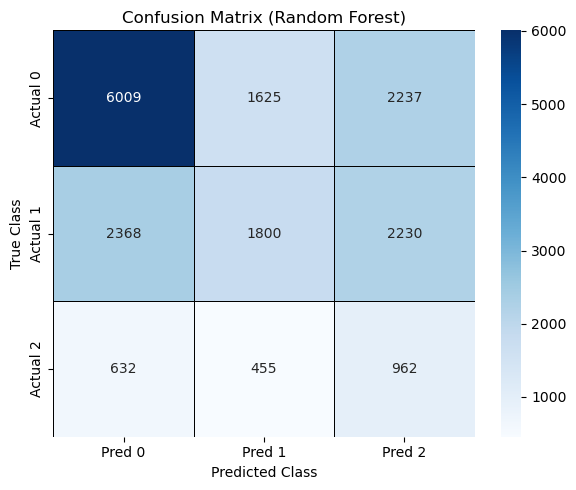

,precision,recall,f1-score,support
Class 0,0.670000,0.610000,0.640000,9871.000000
Class 1,0.460000,0.280000,0.350000,6398.000000
Class 2,0.180000,0.470000,0.260000,2049.000000
Accuracy,0.480000,0.480000,0.480000,0.480000
Macro Avg,0.440000,0.450000,0.410000,18318.000000
Weighted Avg,0.540000,0.480000,0.490000,18318.000000


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_val, y_pred_final)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Pred 0", "Pred 1", "Pred 2"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Confusion Matrix (Random Forest)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

# ===============================
# CLASSIFICATION REPORT TABLE
# ===============================
report = classification_report(
    y_val,
    y_pred_final,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

# Keep only relevant rows
report_df = report_df.loc[
    ["0", "1", "2", "accuracy", "macro avg", "weighted avg"]
]

# Round cleanly for reporting
report_df = report_df.round(2)

# Rename index for clarity
report_df.index = [
    "Class 0",
    "Class 1",
    "Class 2",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

display(
    report_df.style
    .set_caption("Classification Report (Random Forest)")
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("border", "1px solid black"),
                ("background-color", "#f2f2f2"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        }
    ])
)


In [23]:
# ===============================
# CLASSIFICATION REPORT TABLE (2 s.f.)
# ===============================
report = classification_report(
    y_val,
    y_pred_final,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

# Keep only relevant rows
report_df = report_df.loc[
    ["0", "1", "2", "accuracy", "macro avg", "weighted avg"]
]

# Apply 2 significant figures formatting
report_df = report_df.applymap(
    lambda x: f"{x:.2g}" if isinstance(x, (int, float)) else x
)

# Rename index for clarity
report_df.index = [
    "Class 0",
    "Class 1",
    "Class 2",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

display(
    report_df.style
    .set_caption("Classification Report (Random Forest, 2 Significant Figures)")
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("border", "1px solid black"),
                ("background-color", "#f2f2f2"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        }
    ])
)


C:\Users\zerub\AppData\Local\Temp\ipykernel_48540\894593390.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  report_df = report_df.applymap(


,precision,recall,f1-score,support
Class 0,0.67,0.61,0.64,9.9e+03
Class 1,0.46,0.28,0.35,6.4e+03
Class 2,0.18,0.47,0.26,2e+03
Accuracy,0.48,0.48,0.48,0.48
Macro Avg,0.44,0.45,0.41,1.8e+04
Weighted Avg,0.54,0.48,0.49,1.8e+04
